# ENGR 521 Housing Price Prediction Project
## Optimization of Regression Models for King County House Sale Prices

**Team:** Anh Vu & Matthew Kouthong

**Dataset:** [King County House Sales](https://www.kaggle.com/datasets/harlfoxem/housesalesprediction)

**Models:** Linear Regression, Random Forest, XGBoost


### Introduction
Housing price prediction is a supervised machine learning regression problem that aims to estimate house sale prices based on features such as size, number of bedrooms and bathrooms, year built, renovation status, and location, where regression models are used because the output (price) is continuous. In this project, we use three models: Linear Regression, Random Forest Regression, and XGBoost (Extreme Gradient Boosting). We chose this topic because housing price prediction is a practical, real-world problem, and we are curious about how different machine learning models compare in performance. This project allows us to learn and apply regression methods on structured data through model training, evaluation, and comparison.

### Goal
The primary goal of this project is to build and evaluate regression models for housing price prediction using the King County dataset (and potential Snohomish County dataset) that are found on Kaggle. We will compare three models: Linear Regression (baseline model), Random Forest Regression (ensemble decision-tree model), and XGBoost (a boosting-based model that improves predictions by correcting previous errors). Each model will take housing attributes as input and output predicted house prices.
In addition to model comparison, we will focus on feature subset sampling and hyperparameter tuning. Instead of using all available features, we will test smaller optimized subsets of features to evaluate how feature sparsity affects performance. We will also tune key parameters for Random Forest and XGBoost to improve accuracy. Model performance will be evaluated using MAE, RMSE, and R2 score, where lower error and higher R2 indicate better performance. Success is defined as identifying the best-performing combination of model type, feature subset, and tuning strategy.

In [2]:
# Setup
import pandas as pd
import numpy as np

In [3]:
# Load Data
url = "https://raw.githubusercontent.com/anhvuuw/Housing-Price-Prediction-Project/refs/heads/project-branch/kc_house_data.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
display(df.head(20))
display(df.columns)

Shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,20140512T000000,1225000.0,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,20140627T000000,257500.0,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,20150115T000000,291850.0,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,20150415T000000,229500.0,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,20150312T000000,323000.0,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [4]:
# Clean Data

### Feature - Date ###
# Change date to datetime format
clean_date = df.date.apply(lambda x: x.split('T')[0])
# Replace date column with the 'clean_date' variable
df['date'] = clean_date
# Convert date column to Pandas datetime format
df['date'] = pd.to_datetime(df['date'], format = '%Y%m%d')

### Feature (Output) - Price ###
# convert data type to integer (take out pennies)
df.price = df.price.astype(np.int64)
# Drop homes over $4mil
df = df[df.price < 4000000]

### Feature - Bedroom ###
# Drop any 7+ bedroom homes as counts for 7+ bedroom homes are low
df = df[df.bedrooms < 7]
# also drop 0 bedroom homes as that is not realistic for family homes
df = df[df.bedrooms > 0]

### Feature - Bathroom ###
# Drop 0 and 0.5 bathroom homes as that is not realistic for family homes
df = df[df.bathrooms > 0.5]
# Drop any homes that have bathroom counts less than 10
df = df[df.bathrooms != 6.75]
df = df[df.bathrooms != 7.50]
df = df[df.bathrooms != 8.00]
df = df[df.bathrooms != 6.50]
df = df[df.bathrooms != 6.25]
df = df[df.bathrooms != 5.75]
df = df[df.bathrooms != 6.00]
df = df[df.bathrooms != 5.50]
df = df[df.bathrooms != 1.25]

### Feature - Sqft Living ###
# No removal of outliers since any sqft_living over 8000 has already been removed
# print(df[df.sqft_living > 8000])

### Feature - Sqft Lot ###
# remove any sqft lot of size 525000 and over to remove outliers
df = df[df.sqft_lot < 525000]
# print(df.sqft_lot.value_counts())

### Feature - Floors ###
# No removal of outliers since there are decent value counts for all floor types
# print(df[df.floors == 3.5])

### Feature - WaterFront ###
# No removal of the waterfront features are necessary

### Feature - View ###
# Remove houses with 4 views (36 qty) as those are outliers for our analysis
df = df[df.view < 4]
# print(df.view.value_counts())

### Feature - Condition ###
# Remove houses with 1 condition (5 qty) as those are outliers for our analysis
df = df[df.condition > 1]
# print(df.condition.value_counts())

# Outliers
# grade: Houses normally have grade between 1 and 13 -> remove unrealistic values
df = df[df['grade'] >= 1]
df = df[df['grade'] <= 13]

# sqft_above: Very large houses (>6500 sqft) are rare and can skew the model -> remove them
df = df[df['sqft_above'] > 0]
df = df[df['sqft_above'] < 6500]

# sqft_basement: Basement should not be negative and extremely large basements are uncommon -> remove them
df = df[df['sqft_basement'] >= 0]
df = df[df['sqft_basement'] < 3000]

# yr_built: Year built must be positive -> remove invalid data
df = df[df['yr_built'] > 0]

# yr_renovated: 0 means no renovation and remove negative value
df = df[df['yr_renovated'] >= 0]

# zipcode: Zipcode is a category (location), not a numeric value -> convert to string
df['zipcode'] = df['zipcode'].astype(str)

# lat: Latitude should be within King County area -> remove wrong location data
df = df[df['lat'] > 47]
df = df[df['lat'] < 48]

# long: Longitude should be within King County area -> remove wrong location data
df = df[df['long'] > -123]
df = df[df['long'] < -121]

# sqft_living15: Nearby living area should be positive -> remove invalid values
df = df[df['sqft_living15'] > 0]

# sqft_lot15: Extremely large lot sizes (>500000 sqft) are rare and can distort analysis -> remove them
df = df[df['sqft_lot15'] > 0]
df = df[df['sqft_lot15'] < 500000]

# Drop missing data
df_clean = df.dropna()
print(df_clean.shape)
df_clean.head(20)

(21137, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,221900,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,2014-12-09,538000,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,2015-02-25,180000,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,2014-12-09,604000,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,2015-02-18,510000,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503
5,7237550310,2014-05-12,1225000,4,4.50,5420,101930,1.0,0,0,...,11,3890,1530,2001,0,98053,47.6561,-122.005,4760,101930
6,1321400060,2014-06-27,257500,3,2.25,1715,6819,2.0,0,0,...,7,1715,0,1995,0,98003,47.3097,-122.327,2238,6819
7,2008000270,2015-01-15,291850,3,1.50,1060,9711,1.0,0,0,...,7,1060,0,1963,0,98198,47.4095,-122.315,1650,9711
8,2414600126,2015-04-15,229500,3,1.00,1780,7470,1.0,0,0,...,7,1050,730,1960,0,98146,47.5123,-122.337,1780,8113
9,3793500160,2015-03-12,323000,3,2.50,1890,6560,2.0,0,0,...,7,1890,0,2003,0,98038,47.3684,-122.031,2390,7570


In [5]:
# Anh Feature Subset Experiments

# y is the price that we want to predict
y = df_clean['price']

# X is all house features, so we remove columns that are not useful as prediction features
X = df_clean.drop(columns=['price', 'id', 'date'], errors='ignore')

baseline_features = ["sqft_living", "bedrooms", "bathrooms", "sqft_lot"]
location_features = ["zipcode", "lat", "long"]
size_features = ["sqft_living", "sqft_lot", "sqft_above", "sqft_basement"]
condition_features = ["grade", "condition", "yr_built", "yr_renovated"]
view_features = ["waterfront", "view", "floors"]
all_features = list(X.columns)

# We also could combine the feature to train. TODO: discussion
# Can do baseline features combine with Linear Regression, calculate mean square error and compare with more features and stronger models.

# Prepare the data
#   X = all house features
#   y = house price
# Remove unnecessary columns: price, id, date in X

# Split the data
#    80% training data (randomize the dataset)
#    20% testing data (randomize the dataset)
# Choose regression models
#    Linear Regression - Baseline and all feature
#    Random Forest Regression - Anh
#    XGBoost Regression - Matt

# For each feature subset:
#    Select only those features from the dataset
#    For each regression model:
#        Train the model using the training data (optimize input parameters of model)
#        Predict house prices using the testing data
#        Calculate model performance: RMSE, MAE, R² score (can do table or visual bar charts)
#        Save the result

# Compare all results
#    Find which feature subset has the lowest RMSE
#    Find which model has the best R² score
#    Compare baseline features with larger feature groups
#    Decide which feature combination works best for house price prediction
#    Initially: compare each regression model with the baseline model/dataset

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Base Line: Linear Regression
feature_subsets = {
    "Baseline \nFeatures": baseline_features,
    "Location \nFeatures": location_features,
    "Size \nFeatures": size_features,
    "Condition \nFeatures": condition_features,
    "All \nFeatures": all_features,
    "Baseline, \nLocation \nFeatures": baseline_features + location_features,
    "Baseline, \nCondition \nFeatures": baseline_features + condition_features,
    "Baseline, \nLocation, \nCondition Features": baseline_features + location_features + condition_features,
    "Baseline, \nLocation, \nCondition, \nView Features": baseline_features + location_features + condition_features + view_features,
}

# Split dataset
X_train_full, X_test_full, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Linear Regression model
linear_model = LinearRegression()
linear_results = []

for subset_name, features in feature_subsets.items():
    selected_features = [f for f in features if f in X.columns]

    X_train = X_train_full[selected_features]
    X_test = X_test_full[selected_features]

    # Train model
    linear_model.fit(X_train, y_train)

    # Predict
    y_pred = linear_model.predict(X_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Save results
    linear_results.append({
        "Feature Subset": subset_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

linear_results_df = pd.DataFrame(linear_results)
linear_results_df = linear_results_df.sort_values(by="RMSE")
display(linear_results_df)

,Feature Subset,RMSE,MAE,R2 Score
4,All \nFeatures,173028.622003,113467.780305,0.686632
8,"Baseline, \nLocation, \nCondition, \nView Feat...",174214.647881,113908.585765,0.682321
7,"Baseline, \nLocation, \nCondition Features",176642.796905,116490.493924,0.673404
6,"Baseline, \nCondition \nFeatures",191129.620720,130549.810015,0.617637
5,"Baseline, \nLocation \nFeatures",196603.006227,130318.990005,0.595424
3,Condition \nFeatures,211321.038747,142906.496253,0.532583
0,Baseline \nFeatures,219880.880767,154002.100885,0.493949
2,Size \nFeatures,223014.362864,156886.085663,0.479423
1,Location \nFeatures,286060.111314,186462.876193,0.143487


In [7]:
# Matthew Feature Subset Experiments
view_features = ["waterfront", "view", "floors"]
living_proximity_features = ["sqft_living15", "sqft_lot15"]

# feature subset experiments for XGBoost Regression
feature_subset_1 = baseline_features + living_proximity_features
feature_subset_2 = baseline_features + living_proximity_features + location_features
feature_subset_3 = baseline_features + view_features
feature_subset_4 = baseline_features + living_proximity_features + view_features

feature_subsets_xgboost = {
    "Baseline \nFeatures": baseline_features,
    "All Features": all_features,
    "Baseline, \nLiving Proximity": feature_subset_1,
    "Baseline, \nLiving Proximity, \nLocation Features": feature_subset_2,
    "Baseline, \nView Features": feature_subset_3,
    "Baseline, \nLiving Proximity, \nView Features": feature_subset_4
}

feature_subsets_optimized = {
    "Baseline \nFeatures": baseline_features
}


In [8]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

rf_results = []

for subset_name, features in feature_subsets.items():
    selected_features = [f for f in features if f in X.columns]

    X_train = X_train_full[selected_features]
    X_test = X_test_full[selected_features]

    # Train model
    rf_model.fit(X_train, y_train)

    # Predict
    y_pred = rf_model.predict(X_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Save results
    rf_results.append({
        "Feature Subset": subset_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })


# Show Random Forest results
rf_results_df = pd.DataFrame(rf_results)
rf_results_df = rf_results_df.sort_values(by="RMSE")
display(rf_results_df)


# Random Forest Tuning

# rf_configs = {
#     # Original model
#     "n_estimators = 50": {
#         "n_estimators": 50
#     },
#     # Increase number of trees
#     "n_estimators = 100": {
#         "n_estimators": 100
#     },
#     # More trees with limited depth
#     "n_estimators = 200": {
#         "n_estimators": 200,
#         "max_depth": 10
#     },
#     # Balanced model
#     "n_estimators = 200, max_depth: 20, min_samples_split: 5, min_samples_leaf: 2": {
#         "n_estimators": 200,
#         "max_depth": 20,
#         "min_samples_split": 5,
#         "min_samples_leaf": 2
#     },
#     # Stronger regularization
#     "n_estimators = 200, max_depth: 15, min_samples_split: 10, min_samples_leaf: 5": {
#         "n_estimators": 200,
#         "max_depth": 15,
#         "min_samples_split": 10,
#         "min_samples_leaf": 5
#     }
# }

# rf_results_all = {}

# for config_name, params in rf_configs.items():

#     rf_model = RandomForestRegressor(
#         **params,
#         random_state=42,
#         n_jobs=-1
#     )

#     rf_results = []

#     for subset_name, features in feature_subsets.items():

#         selected_features = [
#             f for f in features
#             if f in X.columns
#         ]

#         X_train = X_train_full[selected_features]
#         X_test = X_test_full[selected_features]

#         # Train model
#         rf_model.fit(X_train, y_train)

#         # Predict
#         y_pred = rf_model.predict(X_test)

#         # Calculate metrics
#         rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#         mae = mean_absolute_error(y_test, y_pred)
#         r2 = r2_score(y_test, y_pred)

#         # Save results
#         rf_results.append({
#             "Feature Subset": subset_name,
#             "RMSE": rmse,
#             "MAE": mae,
#             "R2 Score": r2
#         })

#     rf_results_df = pd.DataFrame(rf_results)
#     rf_results_df = rf_results_df.sort_values(by="RMSE")

#     rf_results_all[config_name] = rf_results_df

#     print(config_name)
#     display(rf_results_df)

,Feature Subset,RMSE,MAE,R2 Score
8,"Baseline, \nLocation, \nCondition, \nView Feat...",107186.558021,64007.421151,0.879746
4,All \nFeatures,108223.754901,64633.503300,0.877407
7,"Baseline, \nLocation, \nCondition Features",109409.646102,65221.527129,0.874706
5,"Baseline, \nLocation \nFeatures",118913.724388,71486.072498,0.851993
6,"Baseline, \nCondition \nFeatures",176182.927893,116480.997840,0.675102
1,Location \nFeatures,190115.803134,112691.935251,0.621683
3,Condition \nFeatures,198264.633248,133770.677129,0.588557
0,Baseline \nFeatures,215131.659056,146368.314543,0.515573
2,Size \nFeatures,220286.328877,149964.908677,0.492081


# Change Hyperparameter Comparison
The results showed that increasing the number of trees from 50 to 100 improved model performance, reducing RMSE from approximately 108,224 to 107,628 and increasing the R² score from 0.877 to 0.879 when using all features. Further increasing the number of trees alone did not consistently improve performance, suggesting that the model had largely converged.

Additional tuning of tree depth and node size parameters produced the best overall results.
The configuration with n_estimators=200, max_depth=20, min_samples_split=5, and min_samples_leaf=2 achieved one of the lowest RMSE values (approximately 107,666) and the highest overall predictive accuracy.
In contrast, more aggressive regularization (max_depth=15, min_samples_split=10, min_samples_leaf=5) slightly reduced model performance, indicating that excessive restrictions limited the model's ability to capture important patterns in the data.

# Added feature subset
I added some more feature to subset

neighborhood-level variables (`sqft_living15`, `sqft_lot15`) and engineered variables (`house_age`, `was_renovated`, and `years_since_renovation`)

However, the results showed only marginal changes in RMSE and R² scores compared with the existing feature set.

The best-performing models consistently is still the combination of baseline, location, condition, and view related features. This suggests that housing size, geographic location, property condition, and view characteristics capture most of the information needed to predict sale prices in the King County housing market.

The additional engineered and neighborhood features provided limited incremental predictive value, maybe because it is all read included in location and condition features.

In [9]:
# XGBoost
from xgboost import XGBRegressor

model_xgboost = XGBRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True
)

model_xgboost_2 = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True
)

model_xgboost_3 = XGBRegressor(
    n_estimators=150,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True
)

xgboost_results = []
xgboost_results_location_proximity = []
xgboost_results_model_optimized = []
xgboost_results_model_optimized_2 = []
xgboost_results_model_optimized_3 = []

# convert zipcode column type to categorical data
X_train_full['zipcode'] = X_train_full['zipcode'].astype('category')
X_test_full['zipcode'] = X_test_full['zipcode'].astype('category')

# for using the same feature subsets as linear regression and random forest
for subset_name, features in feature_subsets.items():
    selected_features = [f for f in features if f in X.columns]

    X_train = X_train_full[selected_features]
    X_test = X_test_full[selected_features]

    # Train model
    model_xgboost.fit(X_train, y_train)

    # Predict
    y_pred = model_xgboost.predict(X_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Save results
    xgboost_results.append({
        "Feature Subset": subset_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

# for using same feature subsets for location proximity
for subset_name, features in feature_subsets_xgboost.items():
    selected_features = [f for f in features if f in X.columns]

    X_train = X_train_full[selected_features]
    X_test = X_test_full[selected_features]

    # Train model
    model_xgboost.fit(X_train, y_train)

    # Predict
    y_pred = model_xgboost.predict(X_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Save results
    xgboost_results_location_proximity.append({
        "Feature Subset": subset_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

# for hyperparameterizing the number of decision trees for XGBoost (50,100,150)
for subset_name, features in feature_subsets_optimized.items():
    selected_features = [f for f in features if f in X.columns]

    X_train = X_train_full[selected_features]
    X_test = X_test_full[selected_features]

    # Train model
    model_xgboost.fit(X_train, y_train)
    model_xgboost_2.fit(X_train, y_train)
    model_xgboost_3.fit(X_train, y_train)

    # Predict
    y_pred = model_xgboost.predict(X_test)
    y_pred_2 = model_xgboost_2.predict(X_test)
    y_pred_3 = model_xgboost_3.predict(X_test)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred_2))
    rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred_3))

    mae = mean_absolute_error(y_test, y_pred)
    mae_2 = mean_absolute_error(y_test, y_pred_2)
    mae_3 = mean_absolute_error(y_test, y_pred_3)

    r2 = r2_score(y_test, y_pred)
    r2_2 = r2_score(y_test, y_pred_2)
    r2_3 = r2_score(y_test, y_pred_3)

    # Save results
    xgboost_results_model_optimized.append({
        "Feature Subset": subset_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })

    xgboost_results_model_optimized_2.append({
        "Feature Subset": subset_name,
        "RMSE": rmse_2,
        "MAE": mae_2,
        "R2 Score": r2_2
    })

    xgboost_results_model_optimized_3.append({
        "Feature Subset": subset_name,
        "RMSE": rmse_3,
        "MAE": mae_3,
        "R2 Score": r2_3
    })


# displays same feature subset as linear regression and random forest
xgboost_results_df = pd.DataFrame(xgboost_results)
xgboost_results_df = xgboost_results_df.sort_values(by="RMSE")
display(xgboost_results_df)

# displays location proxmity based features
xgboost_results_location_df = pd.DataFrame(xgboost_results_location_proximity)
xgboost_results_location_df = xgboost_results_location_df.sort_values(by="RMSE")
display(xgboost_results_location_df)

# displays optimized hyperameters of 50, 100, 150 decision trees
xgboost_results_optimized_df = pd.DataFrame(xgboost_results_model_optimized)
xgboost_results_optimized_df = xgboost_results_optimized_df.sort_values(by="RMSE")
display(xgboost_results_optimized_df)

xgboost_results_optimized_2_df = pd.DataFrame(xgboost_results_model_optimized_2)
xgboost_results_optimized_2_df = xgboost_results_optimized_2_df.sort_values(by="RMSE")
display(xgboost_results_optimized_2_df)

xgboost_results_optimized_3_df = pd.DataFrame(xgboost_results_model_optimized_3)
xgboost_results_optimized_3_df = xgboost_results_optimized_3_df.sort_values(by="RMSE")
display(xgboost_results_optimized_3_df)



,Feature Subset,RMSE,MAE,R2 Score
8,"Baseline, \nLocation, \nCondition, \nView Feat...",104932.781837,62134.757812,0.884750
4,All \nFeatures,106248.341841,62540.292969,0.881842
7,"Baseline, \nLocation, \nCondition Features",109205.826658,63495.007812,0.875172
5,"Baseline, \nLocation \nFeatures",121643.356481,71941.796875,0.845120
6,"Baseline, \nCondition \nFeatures",174723.891532,115353.296875,0.680461
3,Condition \nFeatures,192345.789951,129848.492188,0.612756
1,Location \nFeatures,192883.237799,117866.953125,0.610589
0,Baseline \nFeatures,208194.105123,139505.593750,0.546313
2,Size \nFeatures,211701.755496,143144.812500,0.530897


,Feature Subset,RMSE,MAE,R2 Score
1,All Features,106248.341841,62540.292969,0.881842
3,"Baseline, \nLiving Proximity, \nLocation Features",117568.104518,69828.875000,0.855323
5,"Baseline, \nLiving Proximity, \nView Features",191152.058257,128457.445312,0.617548
2,"Baseline, \nLiving Proximity",196164.614628,130914.968750,0.597227
4,"Baseline, \nView Features",204274.445666,136170.125000,0.563235
0,Baseline \nFeatures,208194.105123,139505.593750,0.546313


,Feature Subset,RMSE,MAE,R2 Score
0,Baseline \nFeatures,208194.105123,139505.59375,0.546313


,Feature Subset,RMSE,MAE,R2 Score
0,Baseline \nFeatures,210889.886263,140775.53125,0.534488


,Feature Subset,RMSE,MAE,R2 Score
0,Baseline \nFeatures,214007.779746,142200.640625,0.520621


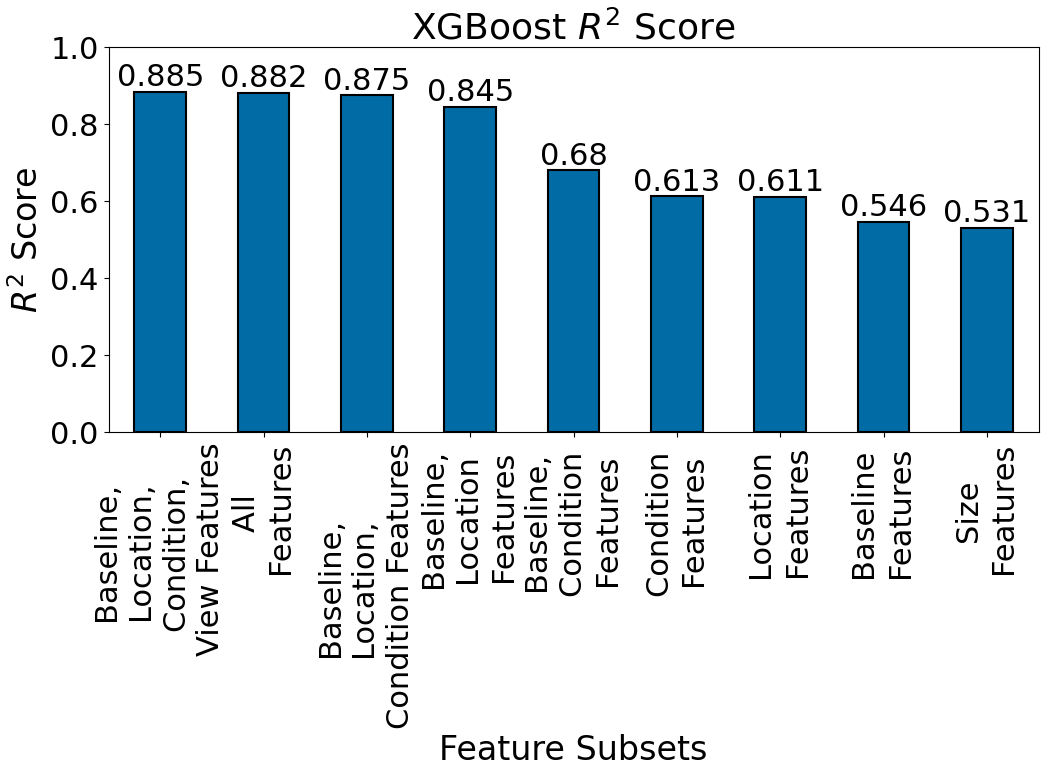

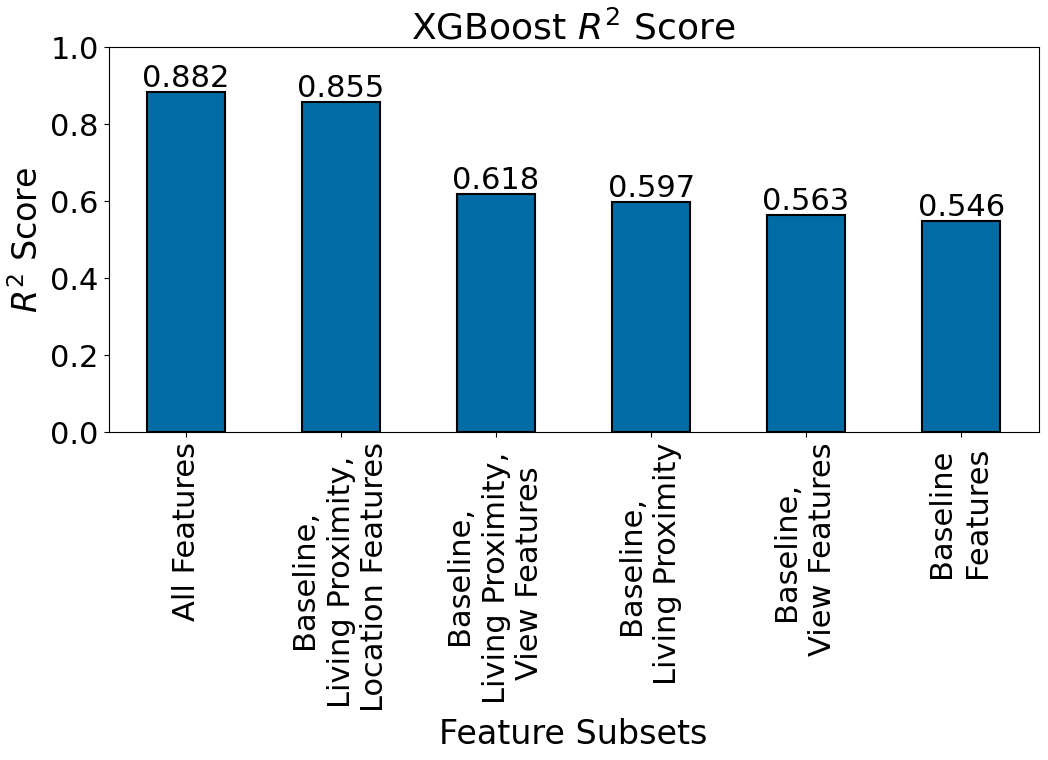

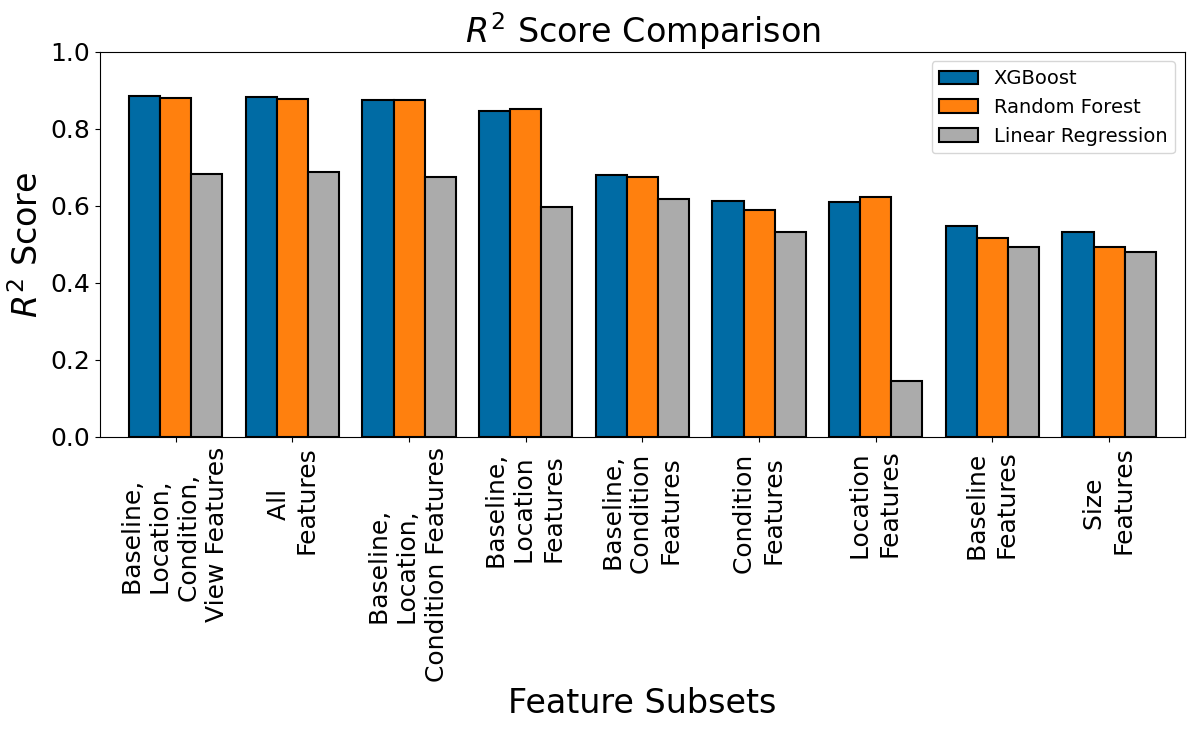

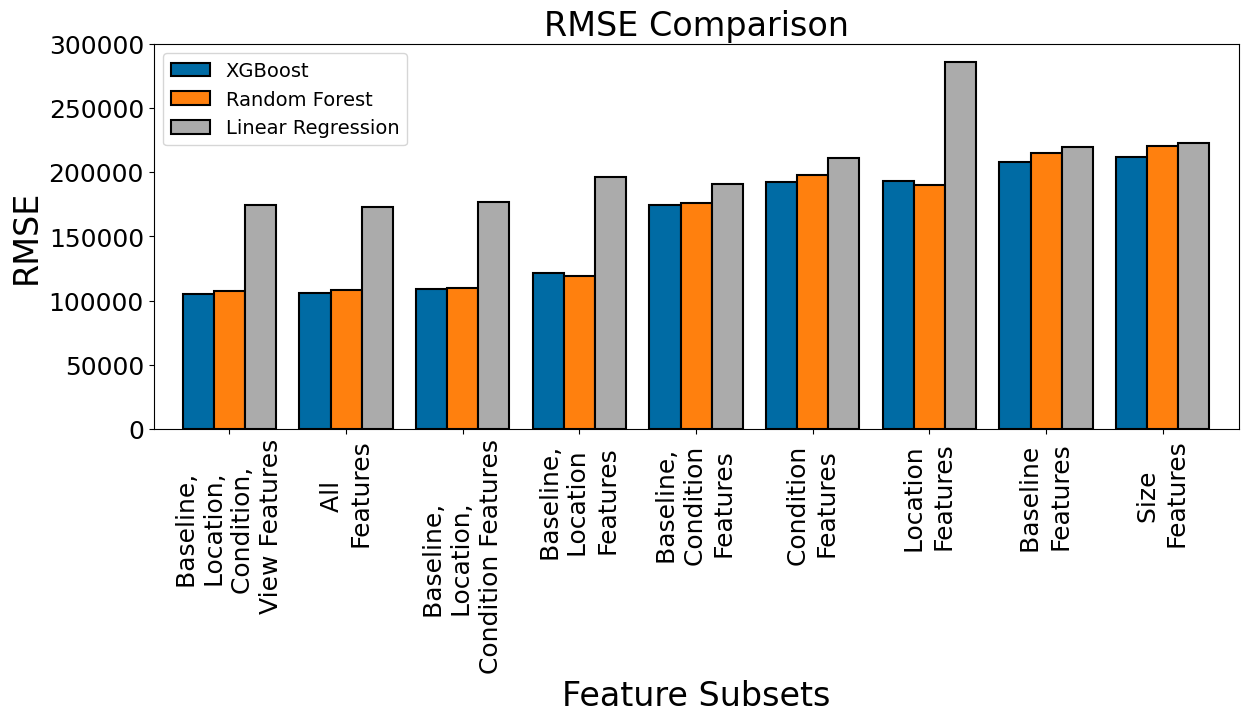

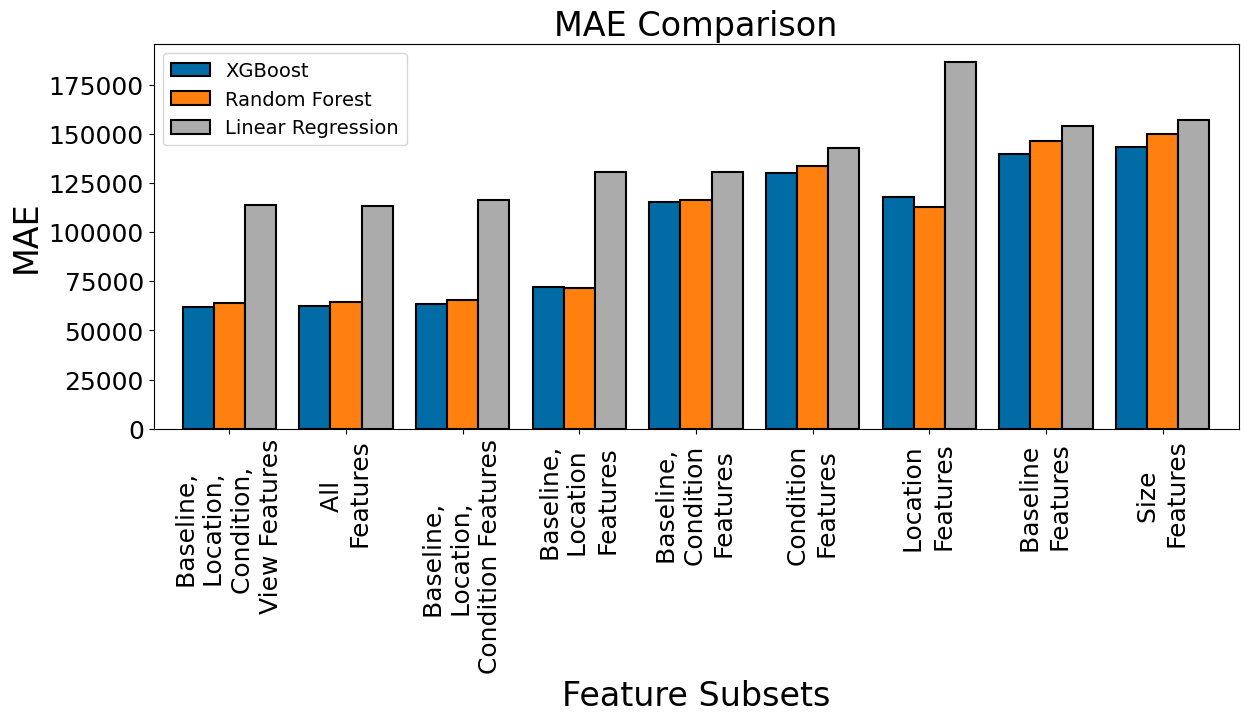

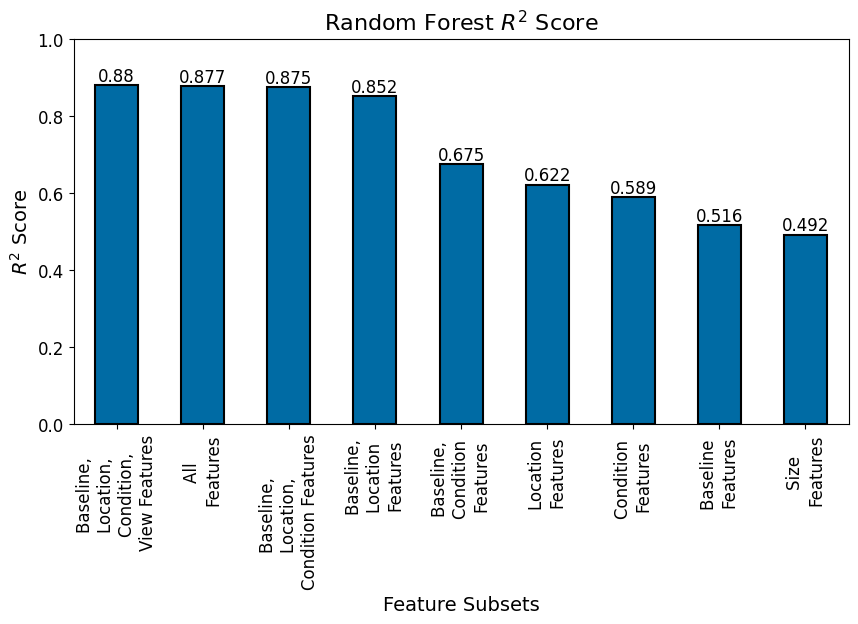

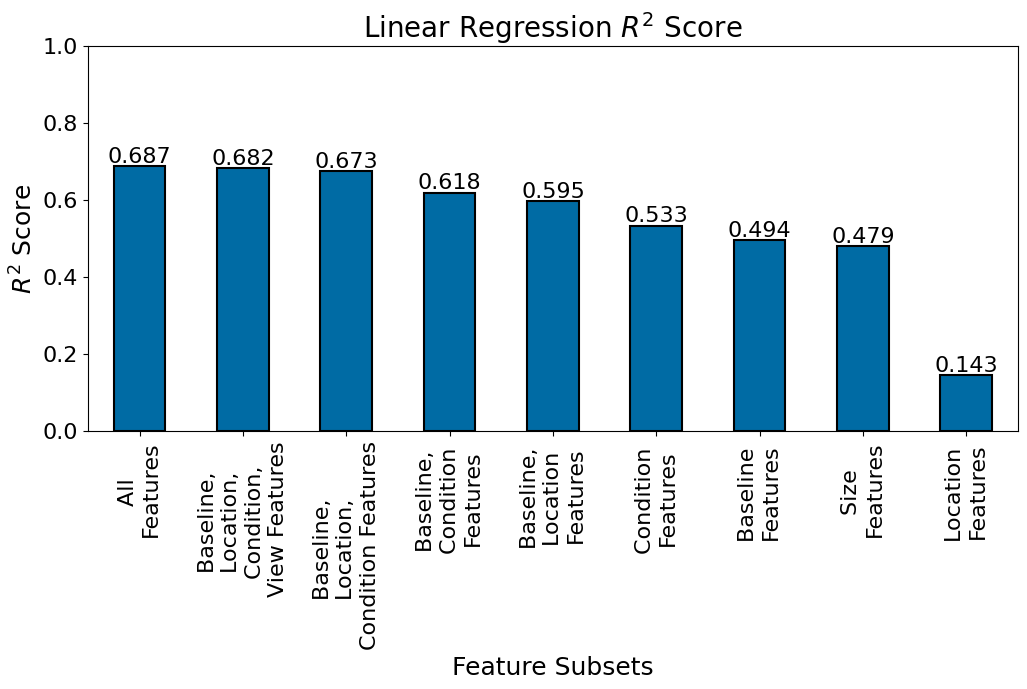

In [10]:
# Combine Results and Visualization
import matplotlib.pyplot as plt
plt.style.use('tableau-colorblind10')

# Xgboost bar plot
ax = xgboost_results_df.plot.bar(x='Feature Subset', y='R2 Score', legend=False,
                                 edgecolor='black', linewidth=1.5, figsize=(12, 5))
ax.bar_label(ax.containers[0], fmt='%.3g', fontsize = 22)
plt.title('XGBoost $R^2$ Score', fontsize = 26)
plt.xlabel('Feature Subsets', fontsize = 24)
plt.xticks(fontsize=22)
plt.ylabel('$R^2$ Score', fontsize = 24)
plt.ylim(0, 1.0)
plt.yticks(fontsize=22)
plt.show()

ax = xgboost_results_location_df.plot.bar(x='Feature Subset', y='R2 Score', legend=False,
                                 edgecolor='black', linewidth=1.5, figsize=(12, 5))
ax.bar_label(ax.containers[0], fmt='%.3g', fontsize = 22)
plt.title('XGBoost $R^2$ Score', fontsize = 26)
plt.xlabel('Feature Subsets', fontsize = 24)
plt.xticks(fontsize=22)
plt.ylabel('$R^2$ Score', fontsize = 24)
plt.ylim(0, 1.0)
plt.yticks(fontsize=22)
plt.show()

# comparison of all regression models with R2 scores
df_xgboost_r2 = xgboost_results_df.set_index('Feature Subset')[['R2 Score']].rename(columns={'R2 Score': 'XGBoost'})
df_rf_r2 = rf_results_df.set_index('Feature Subset')[['R2 Score']].rename(columns={'R2 Score': 'Random Forest'})
df_linear_regression_r2 = linear_results_df.set_index('Feature Subset')[['R2 Score']].rename(columns={'R2 Score': 'Linear Regression'})

df_combined = pd.concat([df_xgboost_r2, df_rf_r2, df_linear_regression_r2],axis=1, join='inner')
ax2 = df_combined.plot(kind="bar", edgecolor='black', linewidth=1.5, width=0.8, figsize=(14, 5))
# for container in ax2.containers:
#     ax2.bar_label(container, fmt='%.2f', fontsize = 14)
plt.title('$R^2$ Score Comparison', fontsize = 24)
plt.xlabel('Feature Subsets', fontsize = 24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylabel('$R^2$ Score', fontsize = 24)
plt.ylim(0, 1.0)
plt.legend(fontsize = 14)
plt.show()

# comparison of all regression models with RMSE
df_xgboost_r2 = xgboost_results_df.set_index('Feature Subset')[['RMSE']].rename(columns={'RMSE': 'XGBoost'})
df_rf_r2 = rf_results_df.set_index('Feature Subset')[['RMSE']].rename(columns={'RMSE': 'Random Forest'})
df_linear_regression_r2 = linear_results_df.set_index('Feature Subset')[['RMSE']].rename(columns={'RMSE': 'Linear Regression'})

df_combined = pd.concat([df_xgboost_r2, df_rf_r2, df_linear_regression_r2],axis=1, join='inner')
ax2 = df_combined.plot(kind="bar", edgecolor='black', linewidth=1.5, width=0.8, figsize=(14, 5))
# for container in ax2.containers:
#     ax2.bar_label(container, fmt='%.2f', fontsize = 14)
plt.title('RMSE Comparison', fontsize = 24)
plt.xlabel('Feature Subsets', fontsize = 24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylabel('RMSE', fontsize = 24)
# plt.ylim(0, 1.0)
plt.legend(fontsize = 14)
plt.show()

# comparison of all regression models with MAE
df_xgboost_r2 = xgboost_results_df.set_index('Feature Subset')[['MAE']].rename(columns={'MAE': 'XGBoost'})
df_rf_r2 = rf_results_df.set_index('Feature Subset')[['MAE']].rename(columns={'MAE': 'Random Forest'})
df_linear_regression_r2 = linear_results_df.set_index('Feature Subset')[['MAE']].rename(columns={'MAE': 'Linear Regression'})

df_combined = pd.concat([df_xgboost_r2, df_rf_r2, df_linear_regression_r2],axis=1, join='inner')
ax2 = df_combined.plot(kind="bar", edgecolor='black', linewidth=1.5, width=0.8, figsize=(14, 5))
# for container in ax2.containers:
#     ax2.bar_label(container, fmt='%.2f', fontsize = 14)
plt.title('MAE Comparison', fontsize = 24)
plt.xlabel('Feature Subsets', fontsize = 24)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.ylabel('MAE', fontsize = 24)
# plt.ylim(0, 1.0)
plt.legend(fontsize = 14)
plt.show()

# Random Forest bar plot
ax = rf_results_df.plot.bar(x='Feature Subset', y='R2 Score', legend=False,
                                 edgecolor='black', linewidth=1.5, figsize=(10, 5))
ax.bar_label(ax.containers[0], fmt='%.3g', fontsize = 12)
plt.title('Random Forest $R^2$ Score', fontsize = 16)
plt.xlabel('Feature Subsets', fontsize = 14)
plt.xticks(fontsize=12)
plt.ylabel('$R^2$ Score', fontsize = 14)
plt.ylim(0, 1.0)
plt.yticks(fontsize=12)
plt.show()

# Linear Regression bar plot
ax = linear_results_df.plot.bar(x='Feature Subset', y='R2 Score', legend=False,
                                 edgecolor='black', linewidth=1.5, figsize=(12, 5))
ax.bar_label(ax.containers[0], fmt='%.3g', fontsize = 16)
plt.title('Linear Regression $R^2$ Score', fontsize = 20)
plt.xlabel('Feature Subsets', fontsize = 18)
plt.xticks(fontsize=16)
plt.ylabel('$R^2$ Score', fontsize = 18)
plt.ylim(0, 1.0)
plt.yticks(fontsize=16)
plt.show()




### Conclusions

#### Best model


#### Feature subset effect


#### Hyperparameter tuning effect


#### Linear vs nonlinear models


#### Limitations


#### Future development
